In [1]:
import pandas as pd  # biblioteka do pracy z danymi tabelarycznymi

# wczytanie danych treningowych
X_train = pd.read_csv(
    "samsung_train.txt",  
    sep=r"\s+",           # separator = dowolna liczba spacji
    header=None           
)

# wczytanie etykiet treningowych
y_train = pd.read_csv(
    "samsung_train_labels.txt",  
    header=None                
)

# wczytanie danych testowych
X_test = pd.read_csv(
    "samsung_test.txt",  
    sep=r"\s+",          # separator = dowolna liczba spacji
    header=None          
)

# wczytanie etykiet testowych
y_test = pd.read_csv(
    "samsung_test_labels.txt",  
    header=None                 
)


print("X_train:", X_train.shape)

print("X_test:", X_test.shape)

print("y_train:", y_train.shape)

print("y_test:", y_test.shape)

X_train: (7352, 561)
X_test: (2947, 561)
y_train: (7352, 1)
y_test: (2947, 1)


desc:
W tym kroku wczytujemy dane treningowe, dane testowe oraz odpowiadające im etykiety. Pliki zawierają 561 cech opisujących aktywność użytkownika telefonu. Na końcu sprawdzamy rozmiary wszystkich zbiorów, aby upewnić się, że dane zostały poprawnie załadowane.

In [2]:
# połączenie danych treningowych i testowych w jeden zbiór
X = pd.concat(
    [X_train, X_test],  # lista łączonych zbiorów
    ignore_index=True   # utworzenie nowej numeracji wierszy
)

# połączenie etykiet treningowych i testowych
y = pd.concat(
    [y_train, y_test],  # lista łączonych etykiet
    ignore_index=True   # utworzenie nowej numeracji wierszy
)

# wyświetlenie rozmiaru połączonego zbioru cech
print("X:", X.shape)

# wyświetlenie rozmiaru połączonych etykiet
print("y:", y.shape)

X: (10299, 561)
y: (10299, 1)


desc:
Ponieważ wykonujemy klasteryzację (Unsupervised Learning), nie musimy korzystać z podziału train/test. Łączymy oba zbiory w jeden większy zbiór danych. Etykiety zachowujemy wyłącznie do późniejszej oceny jakości klasteryzacji.

#skalowanie

In [3]:
from sklearn.preprocessing import StandardScaler  # import skalera

# utworzenie obiektu skalera
scaler = StandardScaler()

# skalowanie wszystkich cech
X_scaled = scaler.fit_transform(X)

# wyświetlenie rozmiaru przeskalowanych danych
print(X_scaled.shape)

(10299, 561)


desc:Algorytmy K-Means, DBSCAN i GMM wykorzystują odległości pomiędzy obserwacjami. Dlatego przed klasteryzacją standaryzujemy dane tak, aby każda cecha miała średnią równą 0 i odchylenie standardowe równe 1.


# Elbow Method

In [4]:
from sklearn.cluster import KMeans  # import algorytmu K-Means

# lista do przechowywania wartości inertia
inertias = []

# sprawdzamy różne liczby klastrów
for k in range(2, 15):

    # utworzenie modelu K-Means
    model = KMeans(
        n_clusters=k,   # liczba klastrów
        random_state=42 # ustalenie ziarna losowości
    )

    # trening modelu
    model.fit(X_scaled)

    # zapisanie wartości inertia
    inertias.append(
        model.inertia_
    )

Dla różnych wartości k obliczamy wartość inertia (SSE). Im mniejsza wartość, tym lepiej dane pasują do klastrów. Szukamy punktu przegięcia na wykresie, który sugeruje optymalną liczbę klastrów.

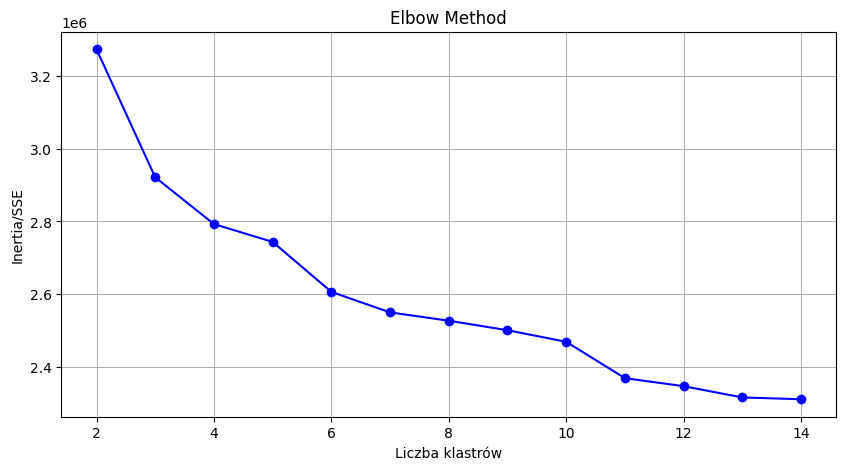

In [5]:
import matplotlib.pyplot as plt  # biblioteka do tworzenia wykresów

# utworzenie figury
plt.figure(figsize=(10, 5))

# narysowanie wykresu
plt.plot(
    range(2, 15),  # liczba klastrów
    inertias,      # wartości inertia
    "bo-"          # niebieskie punkty połączone linią
)

# opis osi X
plt.xlabel("Liczba klastrów")

# opis osi Y
plt.ylabel("Inertia/SSE")

# tytuł wykresu
plt.title("Elbow Method")

# włączenie siatki
plt.grid()

# wyświetlenie wykresu
plt.show()

# Silhouette Score

In [6]:
from sklearn.metrics import silhouette_score  # import metryki silhouette score

# lista do przechowywania wyników
scores = []

# sprawdzamy różne liczby klastrów
for k in range(2, 15):

    # utworzenie modelu K-Means
    model = KMeans(
        n_clusters=k,   # liczba klastrów
        random_state=42 # ustalenie ziarna losowości
    )

    # trening modelu i przypisanie punktów do klastrów
    labels = model.fit_predict(
        X_scaled
    )

    # obliczenie silhouette score
    score = silhouette_score(
        X_scaled,  # dane wejściowe
        labels     # przypisane klastry
    )

    # zapisanie wyniku
    scores.append(score)

desc: Silhouette Score mierzy jednocześnie spójność klastrów i ich separację. Im wyższy wynik, tym lepszy podział danych na klastry.

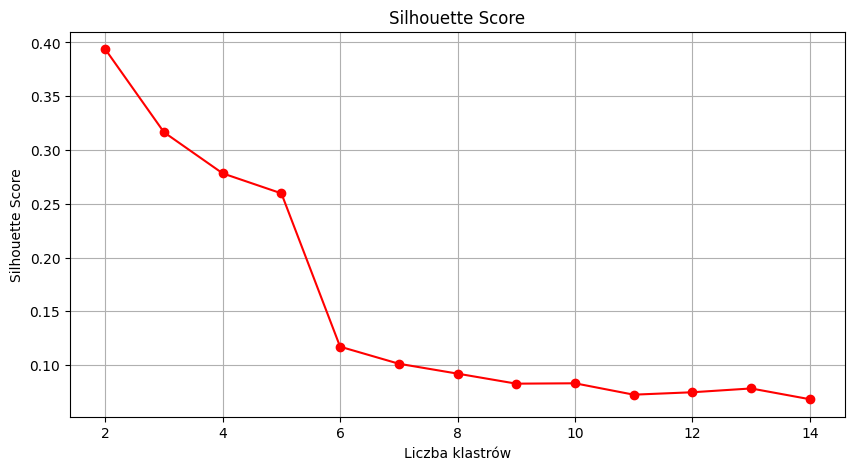

In [7]:
# utworzenie figury
plt.figure(figsize=(10, 5))

# narysowanie wykresu
plt.plot(
    range(2, 15),  # liczba klastrów
    scores,        # silhouette score
    "ro-"          # czerwone punkty połączone linią
)

# opis osi X
plt.xlabel("Liczba klastrów")

# opis osi Y
plt.ylabel("Silhouette Score")

# tytuł wykresu
plt.title("Silhouette Score")

# włączenie siatki
plt.grid()

# wyświetlenie wykresu
plt.show()

In [8]:
for k, score in zip(range(2, 15), scores):
    print(f"k = {k}, score = {score:.4f}")

k = 2, score = 0.3937
k = 3, score = 0.3165
k = 4, score = 0.2783
k = 5, score = 0.2597
k = 6, score = 0.1171
k = 7, score = 0.1012
k = 8, score = 0.0920
k = 9, score = 0.0827
k = 10, score = 0.0830
k = 11, score = 0.0724
k = 12, score = 0.0747
k = 13, score = 0.0782
k = 14, score = 0.0682


# Model K_Means

In [9]:
# utworzenie końcowego modelu K-Means
kmeans = KMeans(
    n_clusters=6,   # liczba aktywności w zbiorze
    random_state=42 # ustalenie ziarna losowości
)

# trening modelu
kmeans.fit(
    X_scaled
)

# zapisanie przypisanych klastrów
clusters_kmeans = kmeans.labels_

desc: Tworzymy finalny model K-Means wykorzystujący 6 klastrów odpowiadających sześciu aktywnościom człowieka.

#ocena K-means za pomoca ARI 

In [10]:
from sklearn.metrics import adjusted_rand_score  # import metryki ARI

# obliczenie ARI
ari_kmeans = adjusted_rand_score(
    y.iloc[:, 0],     # prawdziwe etykiety
    clusters_kmeans   # klastry K-Means
)

# wyświetlenie wyniku
print("ARI KMeans =", ari_kmeans)

ARI KMeans = 0.2850641901721631


KMeans częściowo odnalazł strukturę danych, ale klastry nie odpowiadają dobrze rzeczywistym aktywnościom.

In [11]:
from sklearn.metrics import adjusted_rand_score  # import metryki ARI

# lista na wyniki
results = []

# sprawdzamy różne liczby klastrów
for k in range(2, 15):

    # utworzenie modelu K-Means
    model = KMeans(
        n_clusters=k,   # liczba klastrów
        random_state=42 # ustalenie ziarna losowości
    )

    # trening modelu i przypisanie klastrów
    labels = model.fit_predict(
        X_scaled
    )

    # obliczenie ARI
    ari = adjusted_rand_score(
        y.iloc[:, 0],  # prawdziwe etykiety
        labels         # klastry znalezione przez K-Means
    )

    # zapisanie wyniku
    results.append(
        [k, ari]
    )

# utworzenie DataFrame z wynikami
results_df = pd.DataFrame(
    results,
    columns=[
        "k",
        "ARI"
    ]
)

# wyświetlenie tabeli
print(results_df)

     k       ARI
0    2  0.329611
1    3  0.331882
2    4  0.324653
3    5  0.321280
4    6  0.285064
5    7  0.295215
6    8  0.519368
7    9  0.529479
8   10  0.534589
9   11  0.462230
10  12  0.434400
11  13  0.443965
12  14  0.427020


Dla każdej liczby klastrów od 2 do 14 obliczamy ARI. Dzięki temu możemy sprawdzić, przy jakiej liczbie klastrów K-Means najlepiej odtwarza rzeczywiste aktywności użytkownika.

In [12]:
# sortowanie wyników od najlepszego ARI
results_df.sort_values(
    by="ARI",
    ascending=False
)

,k,ARI
8,10,0.534589
7,9,0.529479
6,8,0.519368
9,11,0.462230
11,13,0.443965
10,12,0.434400
12,14,0.427020
1,3,0.331882
0,2,0.329611
2,4,0.324653


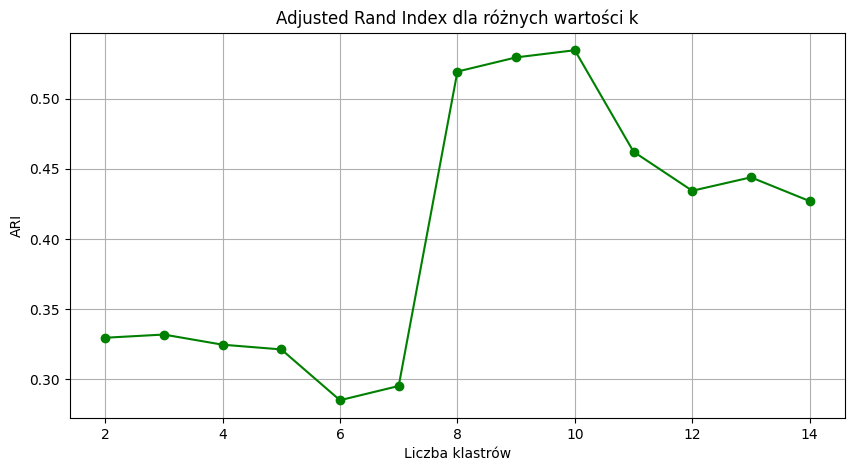

In [13]:
import matplotlib.pyplot as plt  # biblioteka do tworzenia wykresów

# utworzenie figury
plt.figure(figsize=(10, 5))

# narysowanie wykresu
plt.plot(
    results_df["k"],    # liczba klastrów
    results_df["ARI"],  # wartości ARI
    "go-"               # zielone punkty połączone linią
)

# opis osi X
plt.xlabel("Liczba klastrów")

# opis osi Y
plt.ylabel("ARI")

# tytuł wykresu
plt.title("Adjusted Rand Index dla różnych wartości k")

# włączenie siatki
plt.grid()

# wyświetlenie wykresu
plt.show()

Wykres pokazuje zależność pomiędzy liczbą klastrów a zgodnością klasteryzacji z rzeczywistymi aktywnościami. Im wyższy ARI, tym lepszy podział danych.

In [14]:
pd.crosstab(
    clusters_kmeans,
    y.iloc[:,0]
)

,1,2,3,4,5,6
row_0,,,,,,
0,0,0,0,1100,917,1360
1,726,141,868,0,0,0
2,99,10,227,0,0,0
3,810,1031,294,3,0,12
4,87,362,17,0,0,0
5,0,0,0,674,989,572


## Wizualizacja podziału danych przez K-Means

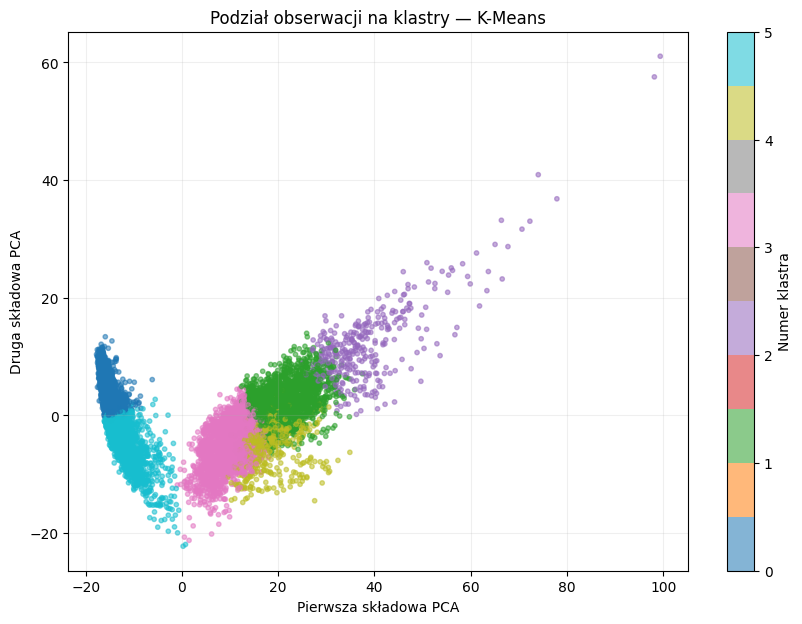

Dwie składowe PCA wyjaśniają 57.0% wariancji.


In [15]:
from sklearn.decomposition import PCA

# Redukujemy 561 cech do dwóch wymiarów wyłącznie na potrzeby wizualizacji.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters_kmeans, cmap="tab10", s=10, alpha=0.55
)
plt.xlabel("Pierwsza składowa PCA")
plt.ylabel("Druga składowa PCA")
plt.title("Podział obserwacji na klastry — K-Means")
plt.colorbar(label="Numer klastra")
plt.grid(alpha=0.2)
plt.show()

print(f"Dwie składowe PCA wyjaśniają {pca.explained_variance_ratio_.sum():.1%} wariancji.")

Każdy kolor oznacza klaster przypisany przez K-Means. PCA służy tu tylko do pokazania danych na płaszczyźnie — model był trenowany na wszystkich 561 przeskalowanych cechach.

# DBSCAN

In [16]:
from sklearn.cluster import DBSCAN  # import algorytmu DBSCAN

# utworzenie modelu DBSCAN
dbscan = DBSCAN(
    eps=10,          # promień sąsiedztwa
    min_samples=10   # minimalna liczba punktów w sąsiedztwie
)

# trening modelu i przypisanie klastrów
clusters_dbscan = dbscan.fit_predict(
    X_scaled
)


DBSCAN grupuje punkty na podstawie ich gęstości. Dodatkowo potrafi oznaczać obserwacje odstające jako szum (-1).

In [17]:
import numpy as np  # biblioteka do obliczeń numerycznych

# wyświetlenie unikalnych etykiet
print(
    np.unique(clusters_dbscan)
)

[-1  0  1  2  3  4  5  6]


-1 = szum
0-6 klastry

In [18]:
# obliczenie ARI dla DBSCAN
ari_dbscan = adjusted_rand_score(
    y.iloc[:, 0],
    clusters_dbscan
)

# wyświetlenie wyniku
print("ARI DBSCAN =", ari_dbscan)

ARI DBSCAN = 0.03353453890057609


bardzo slabe ARI - klastry znalezione przez DBSCAN sa praktycznie losowe i nie odpowiadaja rzeczywistym aktywnosciom

In [19]:
pd.Series(clusters_dbscan).value_counts()

-1    8040
 0    2162
 3      31
 2      16
 1      15
 6      13
 5      12
 4      10
Name: count, dtype: int64

## Wizualizacja podziału danych przez DBSCAN

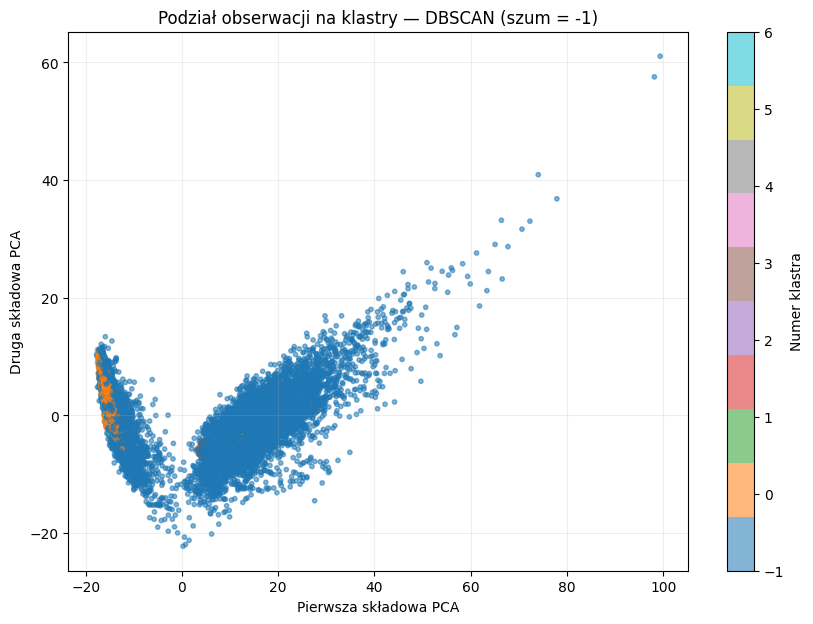

In [20]:
plt.figure(figsize=(10, 7))
dbscan_colors = np.where(clusters_dbscan == -1, -1, clusters_dbscan)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=dbscan_colors, cmap="tab10", s=10, alpha=0.55
)
plt.xlabel("Pierwsza składowa PCA")
plt.ylabel("Druga składowa PCA")
plt.title("Podział obserwacji na klastry — DBSCAN (szum = -1)")
plt.colorbar(label="Numer klastra")
plt.grid(alpha=0.2)
plt.show()

Dominacja koloru odpowiadającego etykiecie `-1` pokazuje, że DBSCAN uznał większość obserwacji za szum. Niewielkie klastry są widoczne jako małe grupy punktów.

DBSCAN większość obserwacji nie należy do żadnego sensownego klastra

# GMM

In [21]:
from sklearn.mixture import GaussianMixture  # model mieszaniny rozkładów Gaussa
from sklearn.metrics import adjusted_rand_score  # metryka ARI

# utworzenie modelu GMM
gmm = GaussianMixture(
    n_components=6,  # liczba klastrów (6 aktywności)
    random_state=42  # ustalenie ziarna losowości
)

# trening modelu
gmm.fit(X_scaled)

# przypisanie obserwacji do klastrów
clusters_gmm = gmm.predict(X_scaled)

# obliczenie ARI
ari_gmm = adjusted_rand_score(
    y.iloc[:, 0],  # prawdziwe etykiety
    clusters_gmm   # klastry znalezione przez GMM
)

print("ARI GMM =", ari_gmm)

ARI GMM = 0.2874395263878364


desc:Model GMM zakłada, że każdy klaster pochodzi z rozkładu Gaussa. W przeciwieństwie do KMeans klastry mogą mieć różne kształty i rozmiar

In [22]:
# tabela krzyżowa klastry vs aktywności
gmm_table = pd.crosstab(
    clusters_gmm,
    y.iloc[:, 0]
)

# wyświetlenie tabeli
print(gmm_table)

0        1     2    3     4     5     6
row_0                                  
0        0     0    0  1321  1311  1484
1      746   142  874     0     0     0
2       99    10  227     0     0     0
3      790  1030  288     3     0    12
4       87   362   17     0     0     0
5        0     0    0   453   595   448


## Wizualizacja podziału danych przez GMM

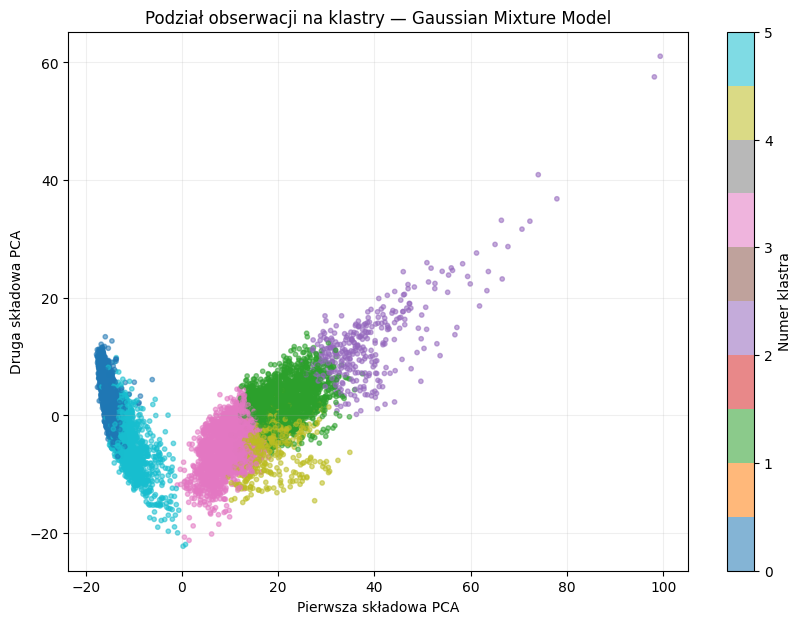

In [23]:
plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=clusters_gmm, cmap="tab10", s=10, alpha=0.55
)
plt.xlabel("Pierwsza składowa PCA")
plt.ylabel("Druga składowa PCA")
plt.title("Podział obserwacji na klastry — Gaussian Mixture Model")
plt.colorbar(label="Numer klastra")
plt.grid(alpha=0.2)
plt.show()

Wykres przedstawia klastry znalezione przez GMM w tej samej dwuwymiarowej projekcji PCA, co ułatwia porównanie podziałów wszystkich algorytmów.

desc:
Tabela pozwala sprawdzić, które aktywności zostały poprawnie rozpoznane przez GMM, a które zostały wymieszane pomiędzy klastrami.

In [24]:
#sprawdzenie roznych covariance_type

In [25]:
from sklearn.mixture import GaussianMixture  # model GMM
from sklearn.metrics import adjusted_rand_score  # metryka ARI

# lista typów macierzy kowariancji
covariance_types = [
    "full",
    "tied",
    "diag",
    "spherical"
]

# lista wyników
gmm_results = []

# test wszystkich wariantów
for cov_type in covariance_types:

    # utworzenie modelu
    gmm = GaussianMixture(
        n_components=6,
        covariance_type=cov_type,
        random_state=42
    )

    # trening modelu
    gmm.fit(X_scaled)

    # predykcja klastrów
    labels = gmm.predict(X_scaled)

    # obliczenie ARI
    ari = adjusted_rand_score(
        y.iloc[:, 0],
        labels
    )

    # zapisanie wyniku
    gmm_results.append(
        [cov_type, ari]
    )

# DataFrame z wynikami
gmm_results = pd.DataFrame(
    gmm_results,
    columns=[
        "Covariance Type",
        "ARI"
    ]
)

# sortowanie od najlepszego wyniku
gmm_results.sort_values(
    by="ARI",
    ascending=False
)

,Covariance Type,ARI
1,tied,0.331499
3,spherical,0.292063
0,full,0.287440
2,diag,0.250345


TIED to najlepszy wynik.
Zakłada, że wszystkie klastry mają ten sam kształt i orientację, ale mogą mieć różne środki.

Dla Samsung HAR okazało się to najlepszym założeniem. Oznacza to, że aktywności użytkowników są podobnie rozłożone w przestrzeni cech i wspólna macierz kowariancji dobrze opisuje dane.

#wykres porownawczy

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "KMeans (k=6)",
        "DBSCAN",
        "Gaussian Mixture"
    ],
    "ARI": [
        ari_kmeans,
        ari_dbscan,
        ari_gmm
    ]
})

comparison.sort_values(
    by="ARI",
    ascending=False
)

,Model,ARI
2,Gaussian Mixture,0.287440
0,KMeans (k=6),0.285064
1,DBSCAN,0.033535


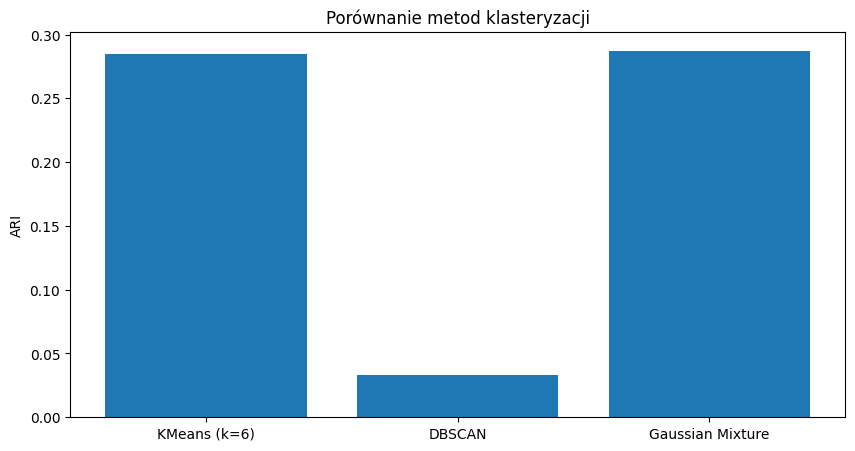

In [27]:
import matplotlib.pyplot as plt  # biblioteka do tworzenia wykresów

# utworzenie figury
plt.figure(figsize=(10, 5))

# wykres słupkowy
plt.bar(
    comparison["Model"],
    comparison["ARI"]
)

# opis osi Y
plt.ylabel("ARI")

# tytuł wykresu
plt.title("Porównanie metod klasteryzacji")

# wyświetlenie wykresu
plt.show()

# Supervised Learning

W tej części wykorzystujemy etykiety aktywności do klasyfikacji. Zachowujemy oryginalny podział na zbiór treningowy i testowy. Dzięki temu wyniki pokazują, jak modele radzą sobie z nowymi obserwacjami, których nie widziały podczas uczenia.

## Przygotowanie danych bez wycieku informacji

In [28]:
from sklearn.preprocessing import StandardScaler

# Skaler dopasowujemy wyłącznie do danych treningowych.
supervised_scaler = StandardScaler()
X_train_scaled = supervised_scaler.fit_transform(X_train)
X_test_scaled = supervised_scaler.transform(X_test)

# Etykiety zapisujemy jako wektory jednowymiarowe.
y_train_supervised = y_train.iloc[:, 0]
y_test_supervised = y_test.iloc[:, 0]

print("Dane treningowe:", X_train_scaled.shape)
print("Dane testowe:", X_test_scaled.shape)

Dane treningowe: (7352, 561)
Dane testowe: (2947, 561)


Skalowanie jest potrzebne szczególnie dla Logistic Regression i KNN. Użycie `fit_transform` tylko na zbiorze treningowym zapobiega przenikaniu informacji ze zbioru testowego do procesu uczenia.

## Trenowanie i porównanie modeli

In [29]:
from time import perf_counter
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

predictions = {}
supervised_results = []

for name, model in models.items():
    start = perf_counter()
    model.fit(X_train_scaled, y_train_supervised)
    y_pred = model.predict(X_test_scaled)
    elapsed = perf_counter() - start

    predictions[name] = y_pred
    supervised_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_supervised, y_pred),
        "F1 macro": f1_score(y_test_supervised, y_pred, average="macro"),
        "Czas [s]": elapsed
    })

supervised_results_df = pd.DataFrame(supervised_results).sort_values(
    "F1 macro", ascending=False
).reset_index(drop=True)
supervised_results_df

,Model,Accuracy,F1 macro,Czas [s]
0,Logistic Regression,0.954869,0.954669,3.312635
1,Random Forest,0.927044,0.925201,6.540661
2,KNN,0.880217,0.876608,0.480654


`Accuracy` pokazuje odsetek poprawnych predykcji, a `F1 macro` nadaje każdej z sześciu aktywności taką samą wagę. Dzięki temu porównanie nie faworyzuje klas występujących częściej.

## Wizualizacja wyników klasyfikacji

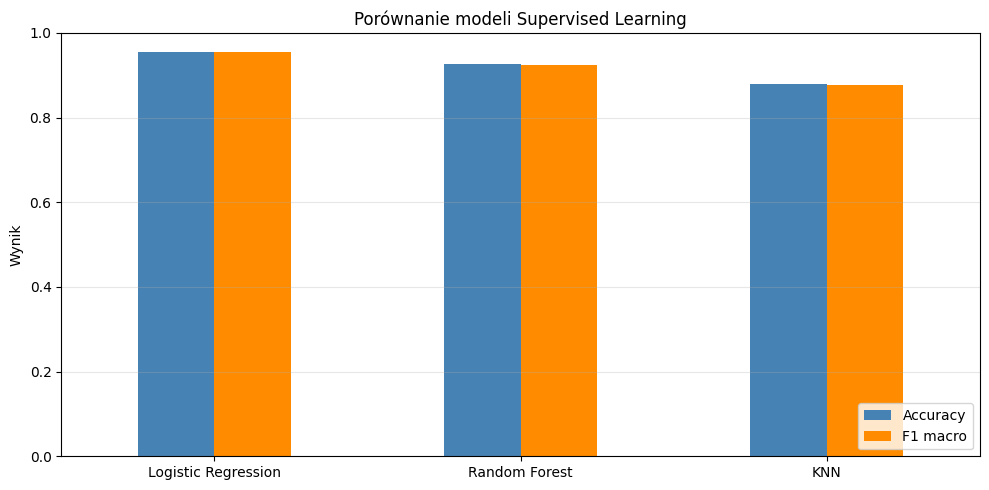

In [30]:
ax = supervised_results_df.set_index("Model")[["Accuracy", "F1 macro"]].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    color=["steelblue", "darkorange"]
)
ax.set_title("Porównanie modeli Supervised Learning")
ax.set_ylabel("Wynik")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Raporty klasyfikacji

In [31]:
activity_names = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

for name, y_pred in predictions.items():
    print(f"\n{name}")
    print(classification_report(
        y_test_supervised,
        y_pred,
        labels=[1, 2, 3, 4, 5, 6],
        target_names=activity_names,
        digits=3,
        zero_division=0
    ))


Logistic Regression
                    precision    recall  f1-score   support

           Walking      0.943     0.994     0.968       496
  Walking Upstairs      0.957     0.947     0.952       471
Walking Downstairs      0.990     0.938     0.963       420
           Sitting      0.968     0.876     0.920       491
          Standing      0.890     0.974     0.930       532
            Laying      0.998     0.993     0.995       537

          accuracy                          0.955      2947
         macro avg      0.958     0.953     0.955      2947
      weighted avg      0.957     0.955     0.955      2947


KNN
                    precision    recall  f1-score   support

           Walking      0.823     0.974     0.892       496
  Walking Upstairs      0.876     0.902     0.889       471
Walking Downstairs      0.962     0.726     0.828       420
           Sitting      0.882     0.760     0.816       491
          Standing      0.799     0.934     0.861       532
          

## Macierze pomyłek

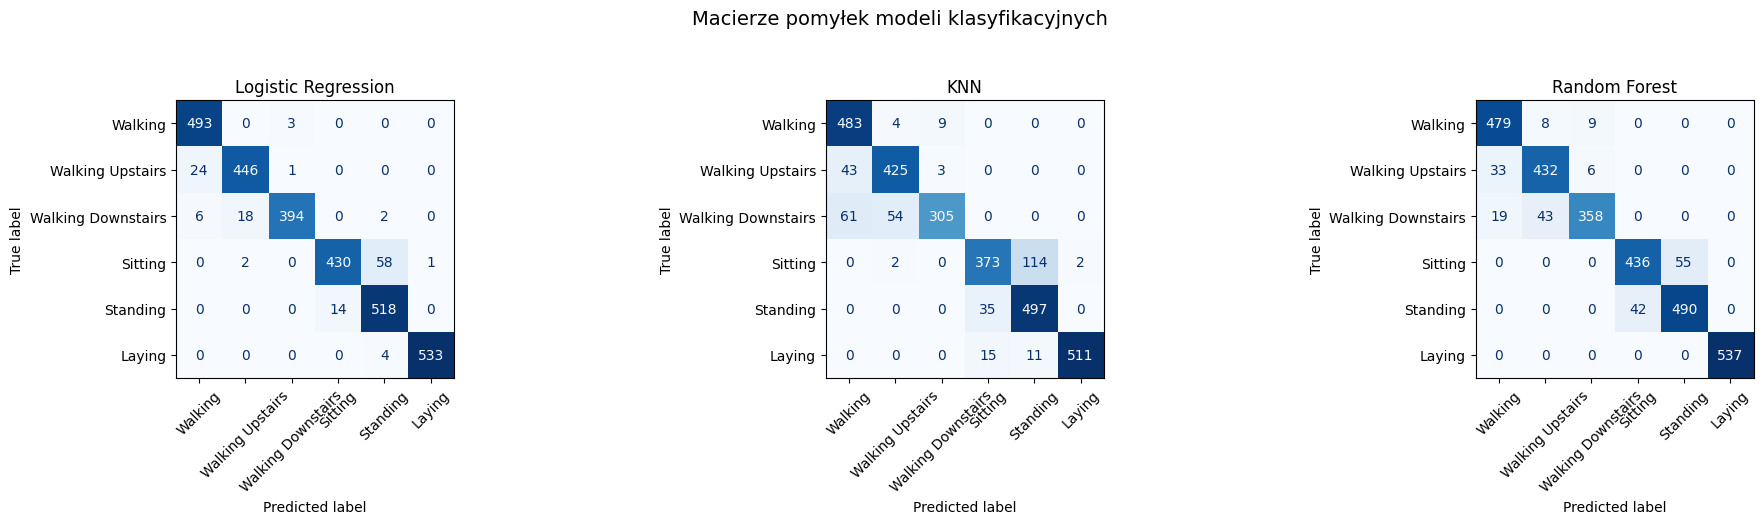

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_supervised,
        y_pred,
        labels=[1, 2, 3, 4, 5, 6],
        display_labels=activity_names,
        cmap="Blues",
        xticks_rotation=45,
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)

plt.suptitle("Macierze pomyłek modeli klasyfikacyjnych", y=1.04, fontsize=14)
plt.tight_layout()
plt.show()

Macierze pomyłek pokazują nie tylko liczbę błędów, ale też to, które aktywności są ze sobą mylone. Najlepszy model wybieramy na podstawie wyników na zbiorze testowym, zwracając szczególną uwagę na `F1 macro`.



# WNIOSKI

Porównanie metod klasteryzacji na zbiorze Samsung HAR

-Przygotowanie danych

Do analizy wykorzystano zbiór Samsung Human Activity Recognition (HAR), zawierający dane z akcelerometru i żyroskopu telefonu komórkowego. Zbiór zawiera 561 cech opisujących ruch użytkownika oraz sześć aktywności:

Walking,
Walking Upstairs,
Walking Downstairs,
Sitting ,
Standing ,
Laying .

Ponieważ zadanie dotyczyło metod Unsupervised Learning, etykiety aktywności nie były wykorzystywane podczas trenowania modeli. Zostały użyte jedynie na etapie oceny jakości klasteryzacji.

Zbiory treningowy i testowy zostały połączone, ponieważ w klasteryzacji nie ma potrzeby klasycznego podziału na dane treningowe i testowe. Celem było znalezienie naturalnej struktury danych w całym zbiorze.

Przed trenowaniem modeli dane zostały przeskalowane przy użyciu StandardScaler.

Dobór liczby klastrów dla KMeans:

 - Do określenia liczby klastrów wykorzystano metodę Elbow Method oraz Silhouette Score.

Elbow Method:

- Na wykresie Elbow Method punkt przegięcia znajdował się w okolicach k=6, co jest zgodne z liczbą aktywności występujących w zbiorze danych.

Silhouette Score

Najwyższy wynik Silhouette Score uzyskano dla:

-k = 2
-Silhouette Score = 0.394

Oznacza to, że dane naturalnie grupują się przede wszystkim w dwie główne kategorie:

- aktywności dynamiczne (walking, walking upstairs,walking downstairs),
- aktywności statyczne (sitting, standing, laying).

Pomimo tego do dalszej analizy wykorzystano również model KMeans z k=6, ponieważ odpowiada on liczbie rzeczywistych aktywności występujących w zbiorze.

KMeans

Dla modelu KMeans przyjęto:

- liczba klastrów = 6

Wynik:

 - ARI = 0.285

Analiza tabeli krzyżowej wykazała, że model stosunkowo dobrze oddzielił aktywności ruchowe od statycznych. Nie potrafił jednak jednoznacznie rozróżnić podobnych aktywności w obrębie tych grup.

Aktywności:

Walking,
Walking Upstairs,
Walking Downstairs

często trafiały do tych samych klastrów.

Podobnie:

Sitting,
Standing,
Laying

również były mieszane pomiędzy klastrami.

Oznacza to, że KMeans potrafił rozpoznać ogólny charakter aktywności, jednak miał trudności z dokładnym rozróżnieniem wszystkich sześciu klas.




DBSCAN

Dla algorytmu DBSCAN uzyskano:

 - ARI = 0.034

Analiza wyników pokazała, że około 78% obserwacji zostało oznaczonych jako szum (etykieta -1).

Algorytm utworzył jedynie jeden większy klaster oraz kilka bardzo małych grup zawierających od kilku do kilkudziesięciu obserwacji.
Tak niski wynik jest prawdopodobnie związany z bardzo dużą liczbą cech (561). DBSCAN opiera się na analizie odległości i gęstości punktów. W przestrzeniach o wysokiej wymiarowości odległości pomiędzy obserwacjami stają się mniej informatywne, co znacząco utrudnia poprawne wykrywanie skupisk danych.

W badanym przypadku DBSCAN okazał się najmniej skuteczną metodą klasteryzacji.



Gaussian Mixture Model (GMM)

Przetestowano cztery warianty parametru covariance_type:

Covariance Type	ARI:
- tied	    0.331
- spherical	0.292
- full	    0.287
- diag	    0.250

Najlepszy wynik uzyskano dla:

 - covariance_type = tied
 - ARI = 0.331

Wariant tied zakłada wspólną macierz kowariancji dla wszystkich klastrów. Dla analizowanego zbioru danych okazało się to najlepszym założeniem.
Wariant spherical osiągnął wynik bardzo zbliżony do KMeans, co jest zgodne z faktem, że oba podejścia preferują klastry o zbliżonym, kulistym kształcie.

Najsłabszy wynik uzyskano dla wariantu diag, który zakłada brak korelacji pomiędzy cechami. W przypadku danych pochodzących z czujników ruchu takie założenie jest zbyt dużym uproszczeniem.

Porównanie metod.
Metoda	ARI:
- GMM (tied)	0.331
- GMM (spherical)	0.292
- GMM (full)	0.287
- KMeans (k=6)	0.285
- GMM (diag)	0.250
- DBSCAN	0.034

Analiza wykazała wyraźną różnicę pomiędzy uczeniem nienadzorowanym i nadzorowanym. Metody klasteryzacji potrafiły częściowo odtworzyć strukturę danych, szczególnie podział na aktywności dynamiczne i statyczne, ale miały trudności z rozróżnieniem wszystkich sześciu aktywności. Najlepszym modelem klasteryzacyjnym był Gaussian Mixture Model z covariance_type="tied", który uzyskał ARI równe 0,331. DBSCAN nie poradził sobie z danymi o wysokiej liczbie wymiarów i większość obserwacji oznaczył jako szum.
W części Supervised Learning najlepszy wynik osiągnęła Logistic Regression: Accuracy 95,49% oraz F1 macro 95,47%. Random Forest uzyskał Accuracy 92,70%, a KNN 88,02%. Najłatwiejszą do rozpoznania aktywnością było leżenie, natomiast najwięcej pomyłek występowało pomiędzy siedzeniem i staniem. Wyniki potwierdzają, że wykorzystanie prawidłowych etykiet podczas trenowania pozwala znacznie dokładniej rozpoznawać aktywności niż poszukiwanie klastrów bez informacji o klasach.

Odpowiedź na pytanie rekrutacyjne:

- KMeans

Algorytm klasteryzacji dzielący dane na k klastrów poprzez iteracyjne wyznaczanie centroidów i przypisywanie do nich obserwacji na podstawie odległości.

- K-Fold

Metoda walidacji modelu. Zbiór danych jest dzielony na k części, a model trenowany i oceniany wielokrotnie na różnych podziałach danych. Nie jest algorytmem uczenia maszynowego.

- K Nearest Neighbors (KNN)

Algorytm klasyfikacji lub regresji. Przewiduje klasę nowej obserwacji na podstawie k najbliższych sąsiadów w zbiorze treningowym.

Pomimo podobnej nazwy, KMeans, K-Fold i KNN rozwiązują zupełnie różne problemy:

- KMeans służy do klasteryzacji,
- K-Fold do walidacji modeli,
- KNN do klasyfikacji lub regresji.